# Cavity Ring-Down Spectroscopy Simulation under Pulsed Excitation

## Overview
This notebook simulates the time-domain behavior of a Fabry-Pérot optical cavity under pulsed laser excitation. The simulation reproduces the results from Lee et al. (1999) and demonstrates how cavity ring-down signals evolve with varying pulse durations and carrier frequency detunings.

## Physical Setup
- **Cavity Type:** Fabry-Pérot cavity
- **Wavelength:** 1064 nm (infrared, Nd:YAG laser line)
- **Cavity Length:** 0.3 m
- **Mirror Reflectivity:** 95% (both mirrors)

## Key Parameters
- Round-trip optical path: characterized by the round-trip time $\tau$
- Cavity detuning: frequency offset relative to cavity resonance (in units of Free Spectral Range, FSR)
- Pulse parameters: duration and peak intensity


## Required Dependencies

This simulation requires:
- **NumPy**: Numerical computations and array operations
- **Matplotlib**: Visualization and plotting
- **oreonspy**: Custom optical cavity simulation described in a separated publication

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import time

import oreonspy as op

## Cavity Parameter Definition

The simulation parameters are based on Figure 2 from Lee et al. (1999), which studies ring-down signal behavior under pulsed excitation.

### Reflectivity and transmissivity
- **Mirror amplitude reflectivity**: $r_a = r_b = \sqrt{0.95}$
- **Mirror amplitude transmissivity**: $t_a = \sqrt{1 - r_a^2}$ (calculated from energy conservation)
- **The cavity loss is verified to be physical**

In [2]:
c = 299792458.  # m/s

# Cavity parameters
#-------------------
# from Jae Yong LEE, et. al. "Time Domain Study on Cavity Ring-Down Signals from a Fabry-Pérot Cavity under Pulsed Laser Excitations" Japanese Journal of Applied Physics, 1999

# Figure 2
r_a = np.sqrt(0.95)
r_b = np.sqrt(0.95)

t_a = np.sqrt(1. - r_a**2)  # Amplitude transmissivity

L = 0.3  # m
#L = int(L/(1064e-9))*(1064e-9) # Tuned cavity FSR=0
#L = int(L/(1064e-9))*(1064e-9)-0.5*(1064e-9)/2 # Tuned cavity FSR=0.35, 0.38 optimal

lambd = 1064e-9  # m
k = 2*np.pi / lambd  # 1/m

Loss = 1. - np.power(t_a,2) - np.power(r_a,2)
if  Loss < 0.:
    print("Check the parameters: Loss is negative, which is unphysical. Loss: {0}".format(Loss))
else:
    print("Loss: {0}".format(Loss))

Loss: 0.0


## Excitation Pulse Definition

The input electric field is modeled as a Gaussian pulse. The full width at half maximum (FWHM) duration can be varied to study how pulse shape affects cavity ring-down behavior. The pulse is parameterized by:
- Duration (FWHM)
- Peak time
- Peak amplitude

In [3]:
def E_in(t, fwhm_duration = 2.4e-9, t_peak=5*2.4e-9, height=1.):
    # Gaussian pulse: 2.4ns duration, peak at t=0.1s, max value 1
    sigma = fwhm_duration / (np.sqrt(8 * np.log(2)))  # Convert FWHM to sigma

    return height * np.exp(-((t - t_peak)**2) / (2 * sigma**2))

## Real-Time Cavity Simulation

The `simulation()` function performs a simulation of the cavity dynamics. Key aspects:

### Simulation Parameters
- **Duration**: 100 ns (sufficient to observe ring-down decay)
- **Sampling Rate**: 2 THz ($2\times10^{12}$ Hz), corresponding to ~0.5 fs time steps
- **Number of Points**: 200,000 (covers the full temporal evolution)

### Detuning
The cavity length is adjusted dynamically to introduce frequency detuning relative to the cavity resonance, measured in units of the Free Spectral Range (FSR). This allows study of on-resonance vs. off-resonance excitation.

### Output
The transmitted field is calculated and its intensity (power) is extracted for visualization and analysis.

In [4]:
def simulation(L, detuning=0., tau_factor=1.):
    impulse_height = .2e-0*10
    duration = 100e-9  # s
    f_calc = 2.e12  # Hz
    number_of_points = int(duration*f_calc)
    print("Number of points: {0}".format(number_of_points))

    L = int(L/(1064e-9))*(1064e-9)-detuning*(1064e-9)/2

    tdata = np.linspace(0, duration, number_of_points)

    ein = np.zeros(len(tdata), dtype=np.complex_)
    rt_sim_res = np.zeros(len(tdata), dtype=np.complex_)
    res = np.zeros(len(tdata), dtype=np.complex_)

    # RT simulation
    cavity = op.Cavity(t_a=t_a , r_a=r_a , r_b=r_b , cavity_length=L)
    tau = 2.*L/c

    cavity.simulation(lambd, 1/(tdata[1]-tdata[0]), initial_input_electric_field=0.)

    cavity.print_sim_params()

    start_time = time.time()

    for idx, t in enumerate(tdata):
        rt_sim_res[idx],_ = cavity.sim_step(E_in(t, fwhm_duration = tau*tau_factor, t_peak=5*2.4e-9, height=impulse_height), 0., 0.)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"RT simulation took {elapsed_time:.4f} seconds")

    return ein, res, rt_sim_res, tdata

## Parameter Sweep Configuration

The following parameter combinations are explored to reproduce Figure 2 from Lee et al. (1999):

### Pulse Duration Factors
- Normalized pulse duration: $0.25\tau$, $0.5\tau$, $1.0\tau$, and $2.0\tau$
- where $\tau$ is the round-trip time of the cavity
- Factor of $\sqrt{2}$ accounts for conversion between amplitude and power domain

### Carrier Frequency Detuning
- **On-resonance**: Detuning = 0 (cavity tuned to laser frequency)
- **Off-resonance 1**: Detuning = 0.25 FSR
- **Off-resonance 2**: Detuning = 0.5 FSR

This creates a 4 by 3 parameter matrix (12 simulations total) showing how ring-down behavior depends on both pulse duration and detuning.

In [5]:
tau_factors = [x * np.sqrt(2) for x in [0.25, .5, 1., 2.]]  # Converion for the pulse duration in field amplitude and power 
detunings = [0., 0.25, 0.5]

Running simulation for tau_factor=0.3535533905932738, detuning=0.0
Number of points: 200000
wave_number: 5905249.348852994
k2j: -11810498.697705988j
requested_sampling_frequency: 1999990000000.0002
initial_input_electric_field: 0.0
sampling_frequency: 2000121642672.7688
num_roundtrips: 1
Theta: 4.999695911813128e-13
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 4003
sampling_frequency_accuracy: 0.9999341783345074
RT simulation took 2.3818 seconds
Running simulation for tau_factor=0.7071067811865476, detuning=0.0
Number of points: 200000
wave_number: 5905249.348852994
k2j: -11810498.697705988j
requested_sampling_frequency: 1999990000000.0002
initial_input_electric_field: 0.0
sampling_frequency: 2000121642672.7688
num_roundtrips: 1
Theta: 4.999695911813128e-13
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 4003
sampling_frequency_accuracy: 0.9999341783345074
RT simulation took 2.3479 seconds
Running simulation for tau_factor=1.4142135623730951, detuning=0.0
Number of

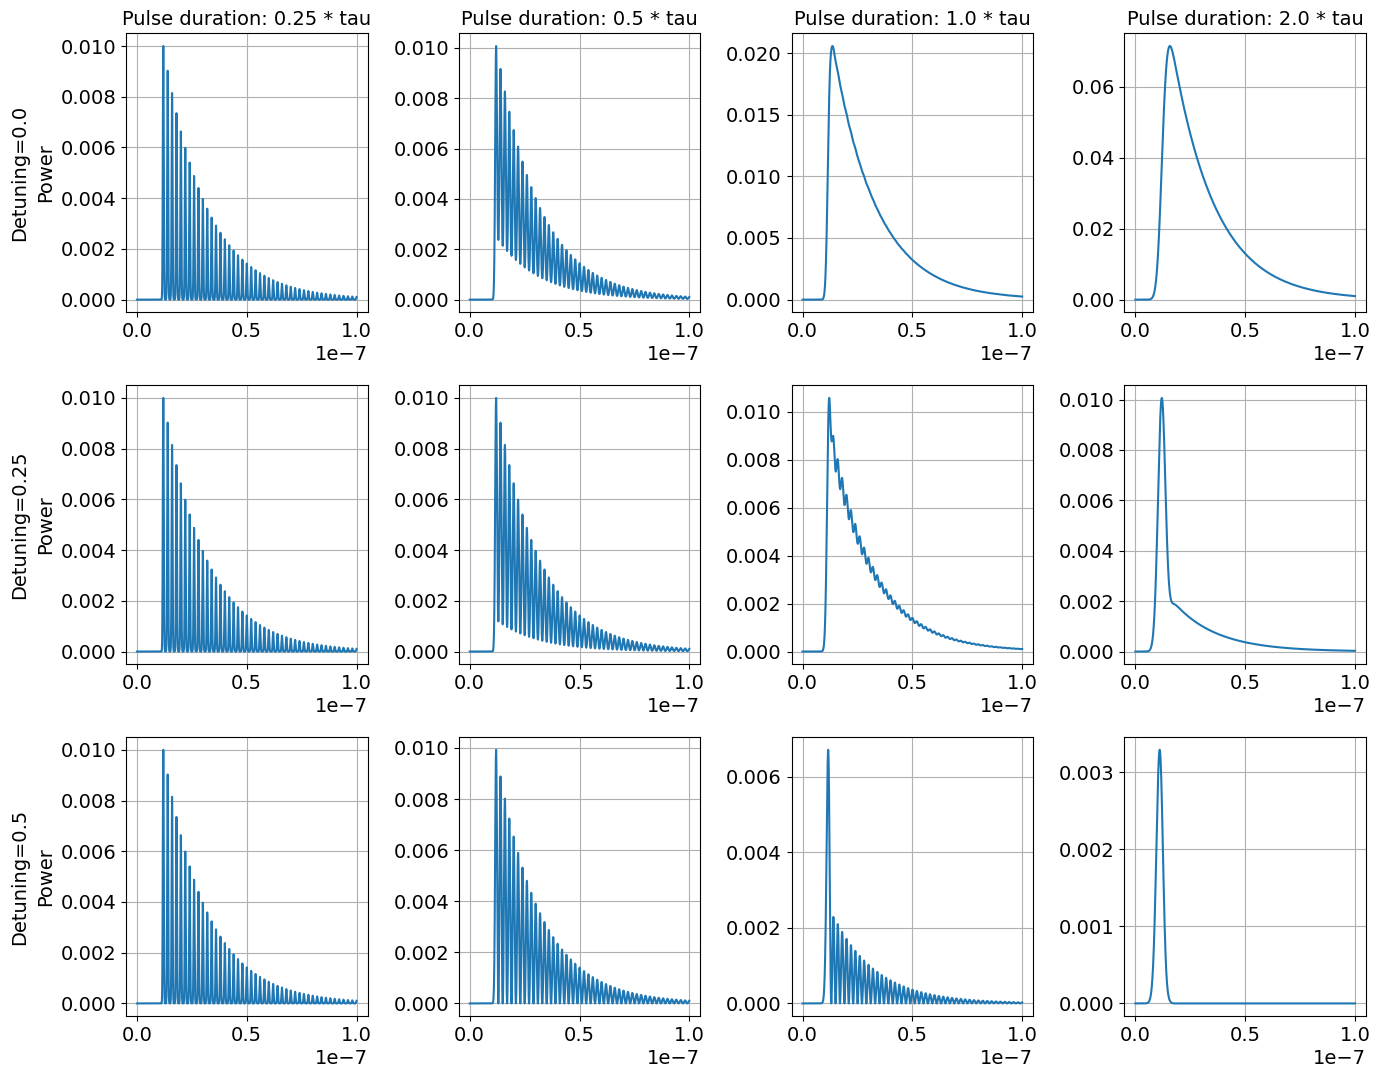

In [6]:
font_size = 14

plt.rcParams['figure.figsize'] = [10, 7]
plt.rcParams.update({'font.size': font_size})

fig, axs = plt.subplots(len(detunings), len(tau_factors), figsize=(14, 11))

for i, detuning in enumerate(detunings):
    for j, tau_factor in enumerate(tau_factors):
        print(f"Running simulation for tau_factor={tau_factor}, detuning={detuning}")
        ein_sim, res_sim, rt_sim_res_sim, tdata_sim = simulation(L, detuning=detuning, tau_factor=tau_factor)
        
        ax = axs[i, j]
        ax.grid(visible=True)
        ax.plot(tdata_sim, (abs(rt_sim_res_sim*t_a)**2), color='C0')

        if j == 0:
            ax.set_ylabel("Power", fontsize=font_size)
        
        # Only add x-label to bottom row
        if i == len(tau_factors) - 1:
            ax.set_xlabel("Time [s]", fontsize=font_size)
        
        # Add title to each subplot
        if i == 0:
            ax.set_title(f"Pulse duration: {tau_factor/ np.sqrt(2)} * tau", fontsize=font_size)
        
        # Add tau_factor label on left side
        if j == 0:
            ax.text(-0.48, 0.5, f"Detuning={detuning}", transform=ax.transAxes, 
                   rotation=90, va='center', fontsize=font_size)

plt.tight_layout()
plt.show()
#plt.savefig("Fig2_Lee.pdf")

## Summary and Remarks

### Validation
This simulation reproduces the numerical results from Lee et al. (1999), validating the oreonspy cavity solver implementation for pulsed excitation scenarios.

### Reproducibility Notes
- All parameters are explicitly defined in this notebook
- The oreonspy library implements cavity field calculations with exact energy conservation
- Simulation timesteps (0.5 fs) are sufficiently fine to resolve optical oscillations at 1064 nm wavelength
- Results are deterministic given fixed input parameters

### References
Lee, J. Y., et al. (1999). "Time Domain Study on Cavity Ring-Down Signals from a Fabry-Pérot Cavity under Pulsed Laser Excitations." Japanese Journal of Applied Physics, 38(1), 10-15.